# 🌍 Climate Extremes in the Mediterranean
## Calculating ETCCDI Indices with `xclim` and CMIP6 SSP5-8.5

The **Mediterranean basin** is one of the most vulnerable regions on Earth to climate change —
it warms faster than the global average, faces more frequent heat waves, and is experiencing
progressive drying.

In this notebook we combine two powerful tools:
- 📡 **CMIP6 SSP5-8.5** — daily future climate projections from the "business-as-usual" emissions scenario
- 🔬 **xclim** — an open-source Python library for computing standardised climate indices

We compare a **near-present period (2015–2030)** with a **mid-century period (2050–2065)** to
quantify how extreme climate events change across the Mediterranean.

---

## 🎯 Learning Objectives

By the end of this notebook you will be able to:

1. Load **daily** CMIP6 data (`tasmax`, `tasmin`, `pr`) from cloud-hosted Zarr stores
2. Subset data to the **Mediterranean region** *before* computing anything (saves bandwidth)
3. Understand how **xclim handles units automatically** — no manual conversions needed
4. Compute five standard **ETCCDI climate indices**:

| Index | Code | What it measures |
|---|---|---|
| ☀️ Summer Days | **SU25** | Days per year with Tmax > 25 °C |
| 🌙 Tropical Nights | **TR20** | Nights per year with Tmin > 20 °C |
| 🔥 Heat Wave Frequency | **HWF** | Number of heat wave events per year |
| 🏜️ Consecutive Dry Days | **CDD** | Longest dry spell per year (days) |
| ⛈️ Max 5-day precipitation | **Rx5day** | Peak rainfall intensity per year (mm) |

5. Create spatial maps comparing near-present and mid-century values
6. Plot annual index time series for a Mediterranean city

> ⚠️ **Prerequisites:** This notebook builds on *Explore CMIP6 SSP5-8.5 Data via Zarr*.
> You should be comfortable with lazy loading, the CMIP6 Zarr catalogue, and Cartopy maps.

## 🗺️ Background: The Mediterranean as a Climate Hotspot

The Mediterranean basin — bordered by southern Europe, North Africa, and the Middle East — is
often described as a **climate change hotspot**: it warms faster than the global average and
the impacts are already visible.

| Indicator | Recent observations | SSP5-8.5 projection (end of century) |
|---|---|---|
| 🌡️ Mean temperature | +1.54 °C since 1900 | +4–5 °C above pre-industrial |
| 🌧️ Summer precipitation | −10 to −20 % | −30 % further decrease  by 2080|
| 🔥 Heat waves | More frequent since 1980s | 5–10× more frequent by 2100 |
| 🏜️ Dry season | Extending into spring/autumn | CDD increases by weeks to months |

**Why use climate indices instead of raw temperature or precipitation?**

Ecosystems, infrastructure, and human health respond to **extremes**, not just average conditions:
- 🌾 A farmer needs to know how many heat-stress days their crops will face
- 🏙️ A city planner needs to know how often heat waves will require emergency response
- 💧 A water manager needs to know how long dry spells will last

Standard indices make these signals **reproducible and comparable** across models, regions, and time periods.

---

### 🔬 What is xclim?

[xclim](https://xclim.readthedocs.io) is an open-source Python library that provides:
- ✅ CF-compliant implementations of **60+ climate indices** (including all standard ETCCDI indices)
- ⚖️ **Automatic unit handling** via `pint` — pass Kelvin data with a `"25 degC"` threshold and xclim converts
- ⚡ Seamless integration with **xarray** and **Dask** for lazy computation on cloud data
- 🛡️ Built-in input validation — helpful error messages if you use the wrong variable

```python
# It really is this simple:
import xclim
summer_days = xclim.atmos.tx_days_above(tasmax=ds.tasmax, thresh="25 degC", freq="YS")
```

In [ ]:
import pandas as pd
import xarray as xr
import xclim

import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature

print(f"xclim version : {xclim.__version__}")
print(f"xarray version: {xr.__version__}")

xr.set_options(display_style='html')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

mpl.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'font.size': 11,
})

xclim version : 0.61.1
xarray version: 2026.4.0


## 🗂️ 1. Load the CMIP6 Zarr Catalogue

For most ETCCDI indices we need **daily** data. In CMIP6 terminology:
- 📅 Monthly data → `table_id = "Amon"` (12 steps/year)
- 📆 Daily data   → `table_id = "day"` (~365 steps/year, ~30× larger)

We need three daily variables:

| Variable | Long name | CMIP6 units |
|---|---|---|
| 🌡️ `tasmax` | Daily maximum near-surface air temperature | K |
| 🌡️ `tasmin` | Daily minimum near-surface air temperature | K |
| 🌧️ `pr` | Daily precipitation flux | kg m⁻² s⁻¹ |

> 💡 **Strategy:** open the global stores lazily, then **immediately subset to the Mediterranean**
> before any computation. This keeps data downloads small — only Mediterranean chunks are
> fetched from Google Cloud Storage.

In [5]:
# Load the CMIP6 Zarr catalogue
df = pd.read_csv("https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv")
print(f"Catalogue loaded: {len(df):,} entries")

# ── Configuration ──────────────────────────────────────────────────────────────
# Change MODEL here to experiment with a different model
MODEL      = "IPSL-CM6A-LR"
EXPERIMENT = "ssp585"
ENSEMBLE   = "r1i1p1f1"
GRID       = "gr"  # regridded to regular lat/lon — easier for cross-model comparisons

def get_store(variable, table="day"):
    """Return the GCS Zarr store path for a given variable and table."""
    hits = df[
        (df.variable_id   == variable)
      & (df.experiment_id == EXPERIMENT)
      & (df.member_id     == ENSEMBLE)
      & (df.table_id      == table)
      & (df.grid_label    == GRID)
      & (df.source_id     == MODEL)
    ]
    if len(hits) == 0:
        raise ValueError(f"No store found: {variable} / {MODEL} / {EXPERIMENT} / {table} / {GRID}")
    return hits.iloc[0].zstore

# Locate daily stores for the three variables
store_tasmax = get_store("tasmax")
store_tasmin = get_store("tasmin")
store_pr     = get_store("pr")

print(f"\nModel: {MODEL}  |  Experiment: {EXPERIMENT}  |  Ensemble: {ENSEMBLE}")
print("\nStores found:")
for var, s in [("tasmax", store_tasmax), ("tasmin", store_tasmin), ("pr", store_pr)]:
    print(f"  {var}: ...{s[-60:]}")

# Open all three stores lazily (metadata only — no data downloaded yet)
ds_tasmax = xr.open_zarr(store_tasmax, storage_options={'token': 'anon'}, consolidated=True)
ds_tasmin = xr.open_zarr(store_tasmin, storage_options={'token': 'anon'}, consolidated=True)
ds_pr     = xr.open_zarr(store_pr,     storage_options={'token': 'anon'}, consolidated=True)

total_gb = (ds_tasmax.nbytes + ds_tasmin.nbytes + ds_pr.nbytes) / 1e9
print(f"\nTotal global data footprint: {total_gb:.1f} GB  (lazy — nothing downloaded yet)")

Catalogue loaded: 523,774 entries

Model: IPSL-CM6A-LR  |  Experiment: ssp585  |  Ensemble: r1i1p1f1

Stores found:
  tasmax: ...P/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/day/tasmax/gr/v20190903/
  tasmin: ...P/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/day/tasmin/gr/v20190903/
  pr: ...ioMIP/IPSL/IPSL-CM6A-LR/ssp585/r1i1p1f1/day/pr/gr/v20190903/

Total global data footprint: 7.8 GB  (lazy — nothing downloaded yet)


## 📍 2. Subset to the Mediterranean

We clip all three variables to the Mediterranean bounding box immediately.
Only Mediterranean chunks will be fetched when we compute indices later.

```
Bounding box:
  🧭 Longitude: −10° to 45°E
  🧭 Latitude:   25° to 50°N
```

We also shift longitudes from the 0–360° convention (used by IPSL-CM6A-LR) to
the −180–180° convention expected by Cartopy.

In [6]:
# Mediterranean domain
LON_MIN, LON_MAX = -10, 45
LAT_MIN, LAT_MAX =  25, 50

def to_mediterranean(ds, var):
    """Shift longitude to -180/180, then clip to the Mediterranean bounding box."""
    ds_180 = ds.assign_coords(lon=(ds.lon + 180) % 360 - 180).sortby("lon")
    return ds_180[var].sel(
        lat=slice(LAT_MIN, LAT_MAX),
        lon=slice(LON_MIN, LON_MAX),
    )

tasmax_med = to_mediterranean(ds_tasmax, "tasmax")
tasmin_med = to_mediterranean(ds_tasmin, "tasmin")
pr_med     = to_mediterranean(ds_pr,     "pr")

print("Mediterranean subset shape (still lazy):")
print(f"  {tasmax_med.sizes['time']} daily steps "
      f"× {tasmax_med.sizes['lat']} lat "
      f"× {tasmax_med.sizes['lon']} lon")
print(f"  Lat range: {float(tasmax_med.lat.min()):.1f}° → {float(tasmax_med.lat.max()):.1f}°N")
print(f"  Lon range: {float(tasmax_med.lon.min()):.1f}° → {float(tasmax_med.lon.max()):.1f}°E")
print(f"\nUnits — tasmax: {tasmax_med.attrs['units']}  |  pr: {pr_med.attrs['units']}")

Mediterranean subset shape (still lazy):
  31411 daily steps × 20 lat × 23 lon
  Lat range: 25.4° → 49.4°N
  Lon range: -10.0° → 45.0°E

Units — tasmax: K  |  pr: kg m-2 s-1


## ⚖️ 3. Units and Climate Periods

### 🔧 How xclim handles units

xclim reads the `units` attribute of each input DataArray and converts automatically
before comparing against the threshold you specify.

| Variable | CMIP6 units | What you write | xclim does |
|---|---|---|---|
| 🌡️ `tasmax`, `tasmin` | K | `thresh="25 degC"` | Converts K to °C internally |
| 🌧️ `pr` | kg m⁻² s⁻¹ | `thresh="1 mm/day"` | Converts kg m⁻² s⁻¹ to mm/day |

> ⚠️ **Do not convert units manually** before passing to xclim — always let it handle this via
> the `thresh` parameter.

### 📅 The two comparison periods

| Period | Years | Purpose |
|---|---|---|
| 🔵 **Near-present** | 2015–2030 | Baseline — what the climate looks like now |
| 🔴 **Mid-century** | 2050–2065 | Future — climate under continued high emissions |

Using 15-year periods averages out natural variability while remaining computationally
tractable. The results are stored as lazy Dask arrays and computed on demand.

In [7]:
# Inspect variable metadata
print("=== Input variable attributes ===")
for name, da in [("tasmax", tasmax_med), ("tasmin", tasmin_med), ("pr", pr_med)]:
    print(f"\n{name}:")
    print(f"  units     : {da.attrs.get('units', 'NOT SET')}")
    print(f"  long_name : {da.attrs.get('long_name', 'NOT SET')[:70]}")

# ── Select the two time periods ───────────────────────────────────────────────
PRESENT = slice("2015", "2030")
FUTURE  = slice("2050", "2065")

tasmax_pres = tasmax_med.sel(time=PRESENT)
tasmax_fut  = tasmax_med.sel(time=FUTURE)
tasmin_pres = tasmin_med.sel(time=PRESENT)
tasmin_fut  = tasmin_med.sel(time=FUTURE)
pr_pres     = pr_med.sel(time=PRESENT)
pr_fut      = pr_med.sel(time=FUTURE)

print("\n=== Time periods ===")
print(f"Near-present: {str(tasmax_pres.time.values[0])[:10]} → "
      f"{str(tasmax_pres.time.values[-1])[:10]}  ({tasmax_pres.sizes['time']} days)")
print(f"Mid-century : {str(tasmax_fut.time.values[0])[:10]} → "
      f"{str(tasmax_fut.time.values[-1])[:10]}  ({tasmax_fut.sizes['time']} days)")

=== Input variable attributes ===

tasmax:
  units     : K
  long_name : Daily Maximum Near-Surface Air Temperature

tasmin:
  units     : K
  long_name : Daily Minimum Near-Surface Air Temperature

pr:
  units     : kg m-2 s-1
  long_name : Precipitation

=== Time periods ===
Near-present: 2015-01-01 → 2030-12-31  (5844 days)
Mid-century : 2050-01-01 → 2065-12-31  (5844 days)


---

## 🌡️ 4. Temperature Indices

Temperature indices quantify **heat stress** — conditions that affect human health,
agriculture, and ecosystems.

| Index | Code | xclim function | Definition |
|---|---|---|---|
| ☀️ Summer Days | SU25 | `xclim.atmos.summer_days` | Days/year with Tmax > 25 °C |
| 🌙 Tropical Nights | TR20 | `xclim.atmos.tropical_nights` | Nights/year with Tmin > 20 °C |
| 🔥 Heat Wave Frequency | HWF | `xclim.atmos.heat_wave_frequency` | Events/year: ≥3 consecutive days with Tmax > 30°C AND Tmin > 22°C |

All xclim functions share the same calling pattern:

```python
index = xclim.atmos.<function>(
    <variable>=<DataArray>,   # variable keyword matches the function
    thresh="<value> <unit>",  # human-readable threshold — xclim converts units
    freq="YS",                # output frequency: YS=yearly, MS=monthly, QS-DEC=seasonal
)
# result is a lazy DataArray; call .compute() to trigger download + calculation
```

### ☀️ Index 1 — Summer Days (SU25)

**Definition:** Number of days per year when the daily maximum temperature exceeds 25 °C.

```
SU25 = count( Tmax_day > 25 °C )  for each year
```

This is the simplest heat index, but it directly measures the length of the thermal "summer".
In the Mediterranean, summer days are already common in July–August. What changes under warming
is that the warm season **extends into spring and autumn**.

> 💡 **Threshold choice:** 25 °C is the standard ETCCDI definition. For Mediterranean conditions
> you may also want SU35 (Tmax > 35 °C) to capture very hot days with crop damage potential.
> We explore this in Exercise 1.

Computing Summer Days (SU25) …  streams data from GCS, please wait
Output units: days

Mediterranean-average SU25:
  Near-present (2015–2030): 117 days/year
  Mid-century  (2050–2065): 144 days/year


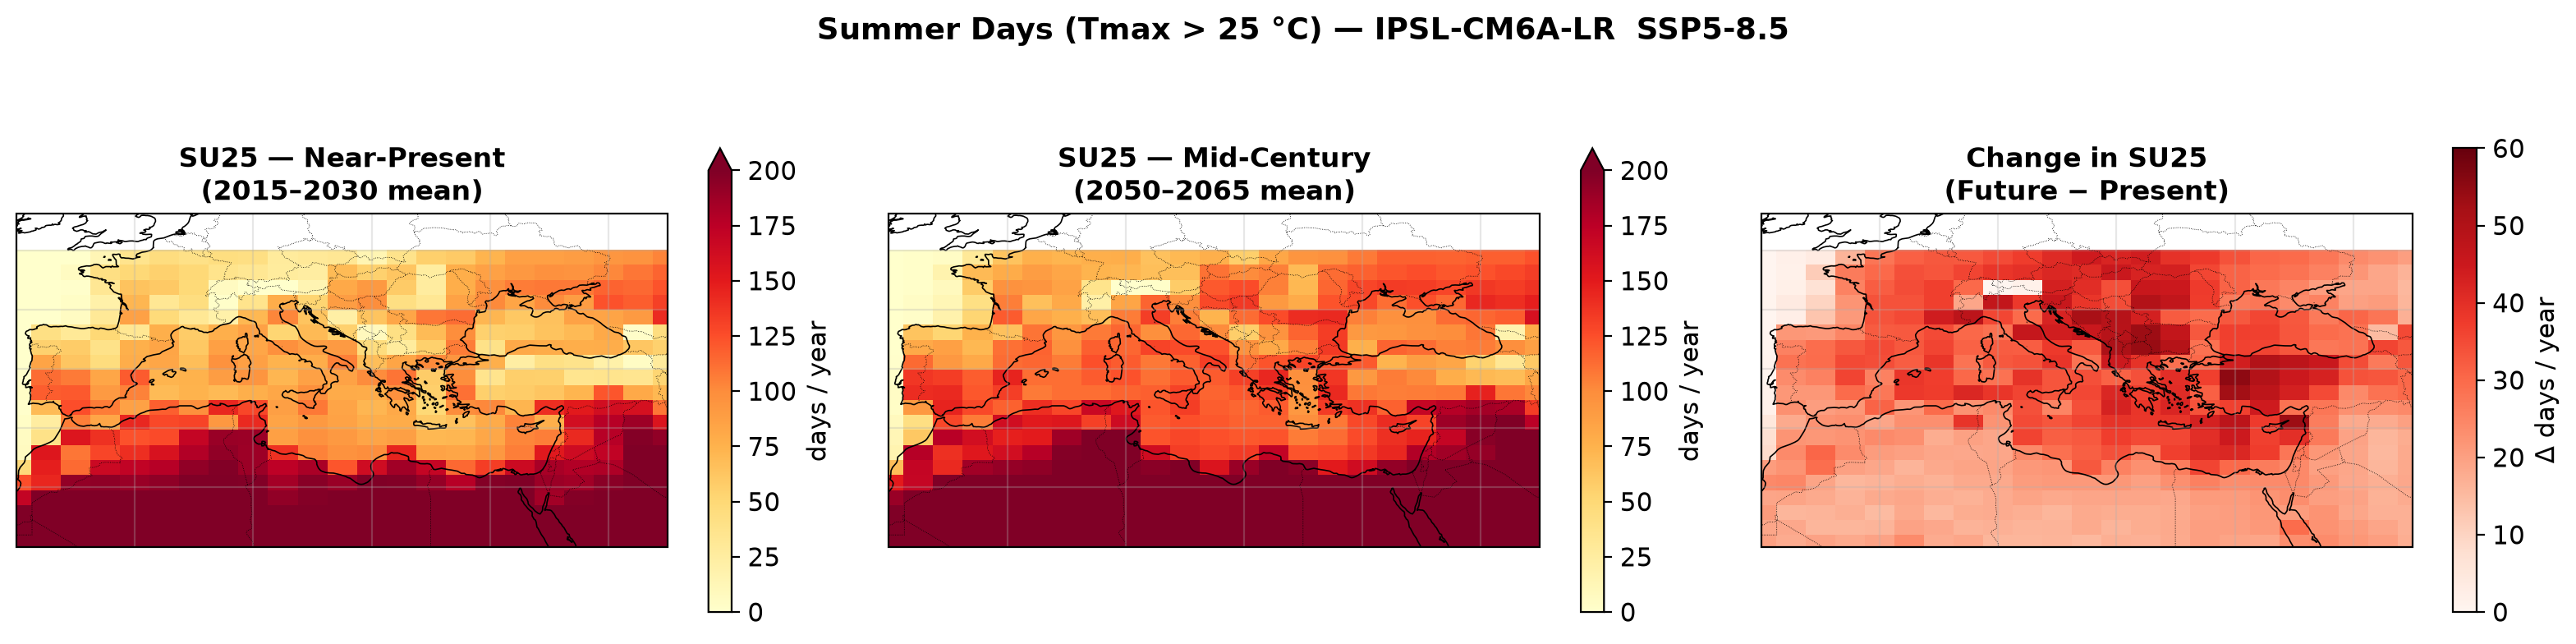

In [ ]:
print("Computing Summer Days (SU25) …  streams data from GCS, please wait")

su_pres = xclim.atmos.tx_days_above(tasmax=tasmax_pres, thresh="25 degC", freq="YS")
su_fut = xclim.atmos.tx_days_above(tasmax=tasmax_fut, thresh="25 degC", freq="YS")

# Average over all years in each period and trigger computation
su_pres_mean = su_pres.mean("time").compute()
su_fut_mean  = su_fut.mean("time").compute()

print(f"Output units: {su_pres.attrs.get('units', 'days')}")
print(f"\nMediterranean-average SU25:")
print(f"  Near-present (2015–2030): {float(su_pres_mean.mean()):.0f} days/year")
print(f"  Mid-century  (2050–2065): {float(su_fut_mean.mean()):.0f} days/year")

# ── Maps ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()})

for data, ax, title in [
    (su_pres_mean, axes[0], "SU25 — Near-Present\n(2015–2030 mean)"),
    (su_fut_mean,  axes[1], "SU25 — Mid-Century\n(2050–2065 mean)"),
]:
    data.plot(ax=ax, cmap="YlOrRd", vmin=0, vmax=200,
              cbar_kwargs={"shrink": 0.85, "label": "days / year"},
              transform=ccrs.PlateCarree())
    ax.set_title(title)

(su_fut_mean - su_pres_mean).plot(
    ax=axes[2], cmap="Reds", vmin=0, vmax=60,
    cbar_kwargs={"shrink": 0.85, "label": "Δ days / year"},
    transform=ccrs.PlateCarree())
axes[2].set_title("Change in SU25\n(Future − Present)")

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])
    ax.gridlines(draw_labels=False, alpha=0.3)

fig.suptitle(f"Summer Days (Tmax > 25 °C) — {MODEL}  SSP5-8.5",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 🌙 Index 2 — Tropical Nights (TR20)

**Definition:** Number of nights per year when the daily minimum temperature stays **above 20 °C**.

```
TR20 = count( Tmin_night > 20 °C )  for each year
```

Tropical nights capture **overnight heat stress**. When nights don't cool down, the human body
cannot thermoregulate effectively — a major driver of heat-related mortality.

In many northern Mediterranean cities, tropical nights were rare events before the 1990s.
Under high emissions they are projected to become **common midsummer occurrences** by mid-century.

> 🏥 **Why does the nighttime matter?**
> During a heat wave, the body relies on cooler nights to recover. When Tmin stays above 20 °C,
> this recovery is impaired. Several studies show that excess mortality during heat waves is
> more strongly correlated with Tmin than with Tmax.

Computing Tropical Nights (TR20) …
Mediterranean-average TR20:
  Near-present (2015–2030): 82 nights/year
  Mid-century  (2050–2065): 112 nights/year


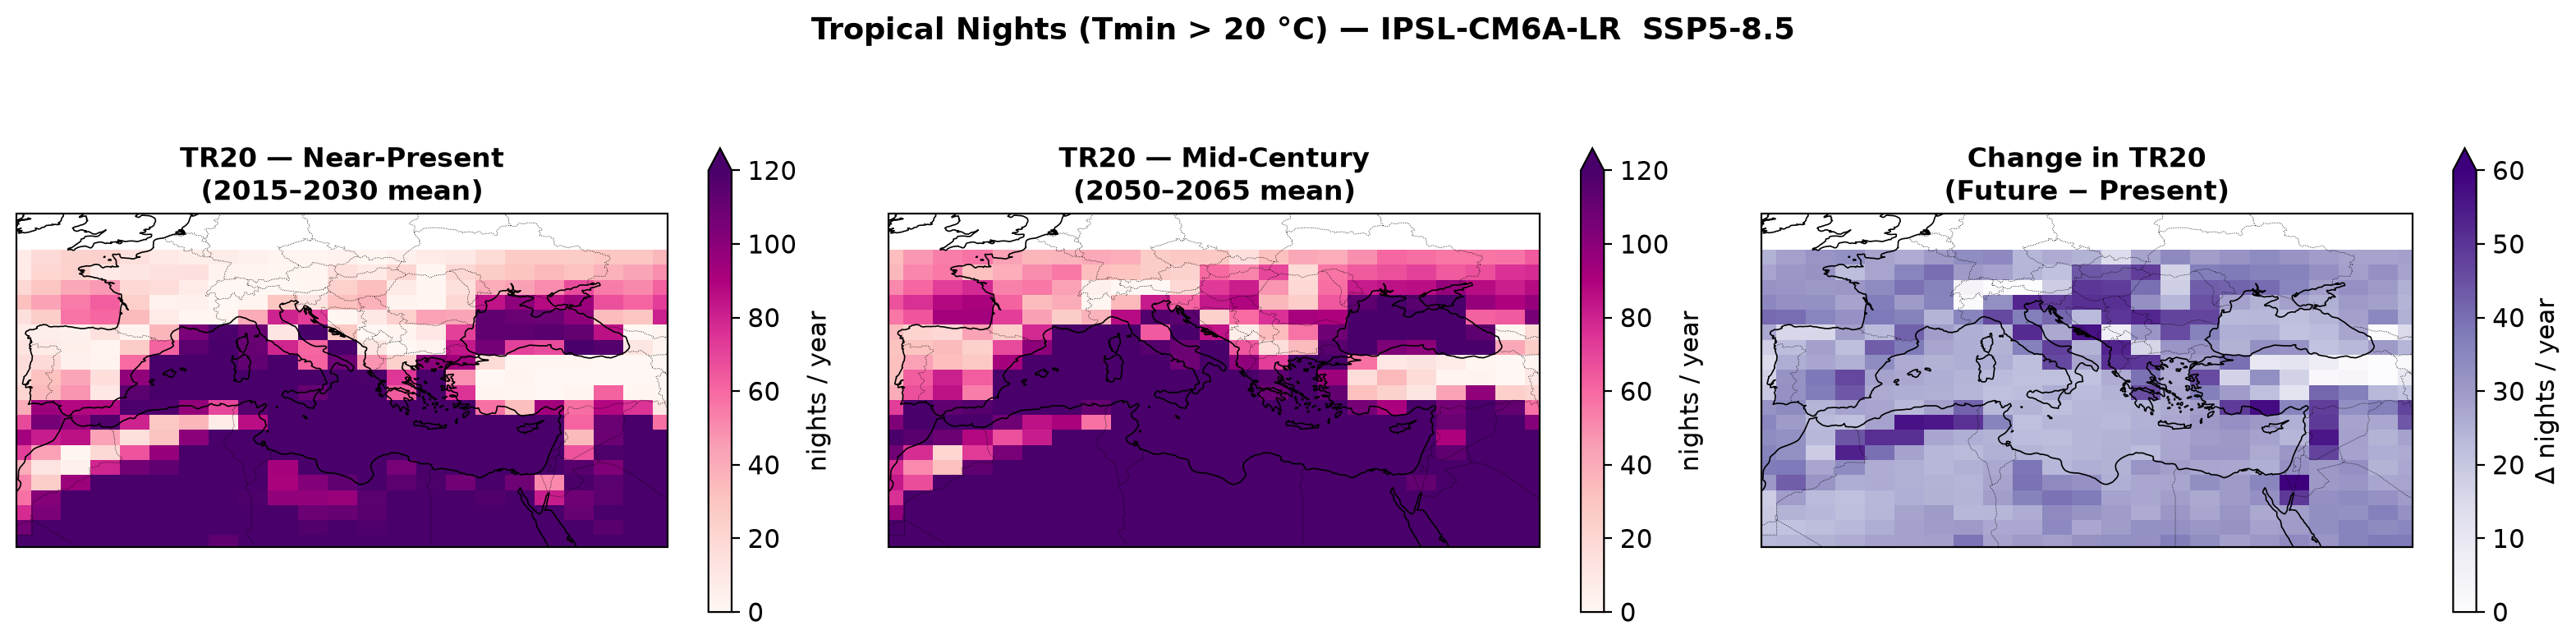

In [10]:
print("Computing Tropical Nights (TR20) …")

tr_pres = xclim.atmos.tropical_nights(tasmin=tasmin_pres, thresh="20 degC", freq="YS")
tr_fut  = xclim.atmos.tropical_nights(tasmin=tasmin_fut,  thresh="20 degC", freq="YS")

tr_pres_mean = tr_pres.mean("time").compute()
tr_fut_mean  = tr_fut.mean("time").compute()

print(f"Mediterranean-average TR20:")
print(f"  Near-present (2015–2030): {float(tr_pres_mean.mean()):.0f} nights/year")
print(f"  Mid-century  (2050–2065): {float(tr_fut_mean.mean()):.0f} nights/year")

fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()})

for data, ax, title in [
    (tr_pres_mean, axes[0], "TR20 — Near-Present\n(2015–2030 mean)"),
    (tr_fut_mean,  axes[1], "TR20 — Mid-Century\n(2050–2065 mean)"),
]:
    data.plot(ax=ax, cmap="RdPu", vmin=0, vmax=120,
              cbar_kwargs={"shrink": 0.85, "label": "nights / year"},
              transform=ccrs.PlateCarree())
    ax.set_title(title)

(tr_fut_mean - tr_pres_mean).plot(
    ax=axes[2], cmap="Purples", vmin=0, vmax=60,
    cbar_kwargs={"shrink": 0.85, "label": "Δ nights / year"},
    transform=ccrs.PlateCarree())
axes[2].set_title("Change in TR20\n(Future − Present)")

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

fig.suptitle(f"Tropical Nights (Tmin > 20 °C) — {MODEL}  SSP5-8.5",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 🔥 Index 3 — Heat Wave Frequency (HWF)

**Definition:** Number of heat wave events per year, where a heat wave is **at least 3 consecutive
days** satisfying BOTH:
- 🌡️ Daily maximum temperature > **30 °C**
- 🌡️ Daily minimum temperature > **22 °C**

```
HWF = number of such events per year
```

Why a **joint criterion** on Tmax AND Tmin?
- Tmax > 30 °C alone captures hot days, but misses nights that stay warm
- Adding Tmin > 22 °C selects the most dangerous episodes — hot days with no overnight cooling
- The `window=3` requirement filters out isolated single hot days

These thresholds are calibrated for the Mediterranean, where summer Tmax already commonly
exceeds 25 °C — a 30 °C threshold is needed to identify genuinely extreme events.

> 💡 **HWF vs HWI:** xclim also provides `heat_wave_index` which counts the total **number of days**
> in heat waves (not the number of events). Both are useful — HWF tells you *how often* heat waves
> happen, HWI tells you *how much time* is spent in them.

Computing Heat Wave Frequency (HWF) …
Mediterranean-average HWF:
  Near-present (2015–2030): 2.11 events/year
  Mid-century  (2050–2065): 2.91 events/year


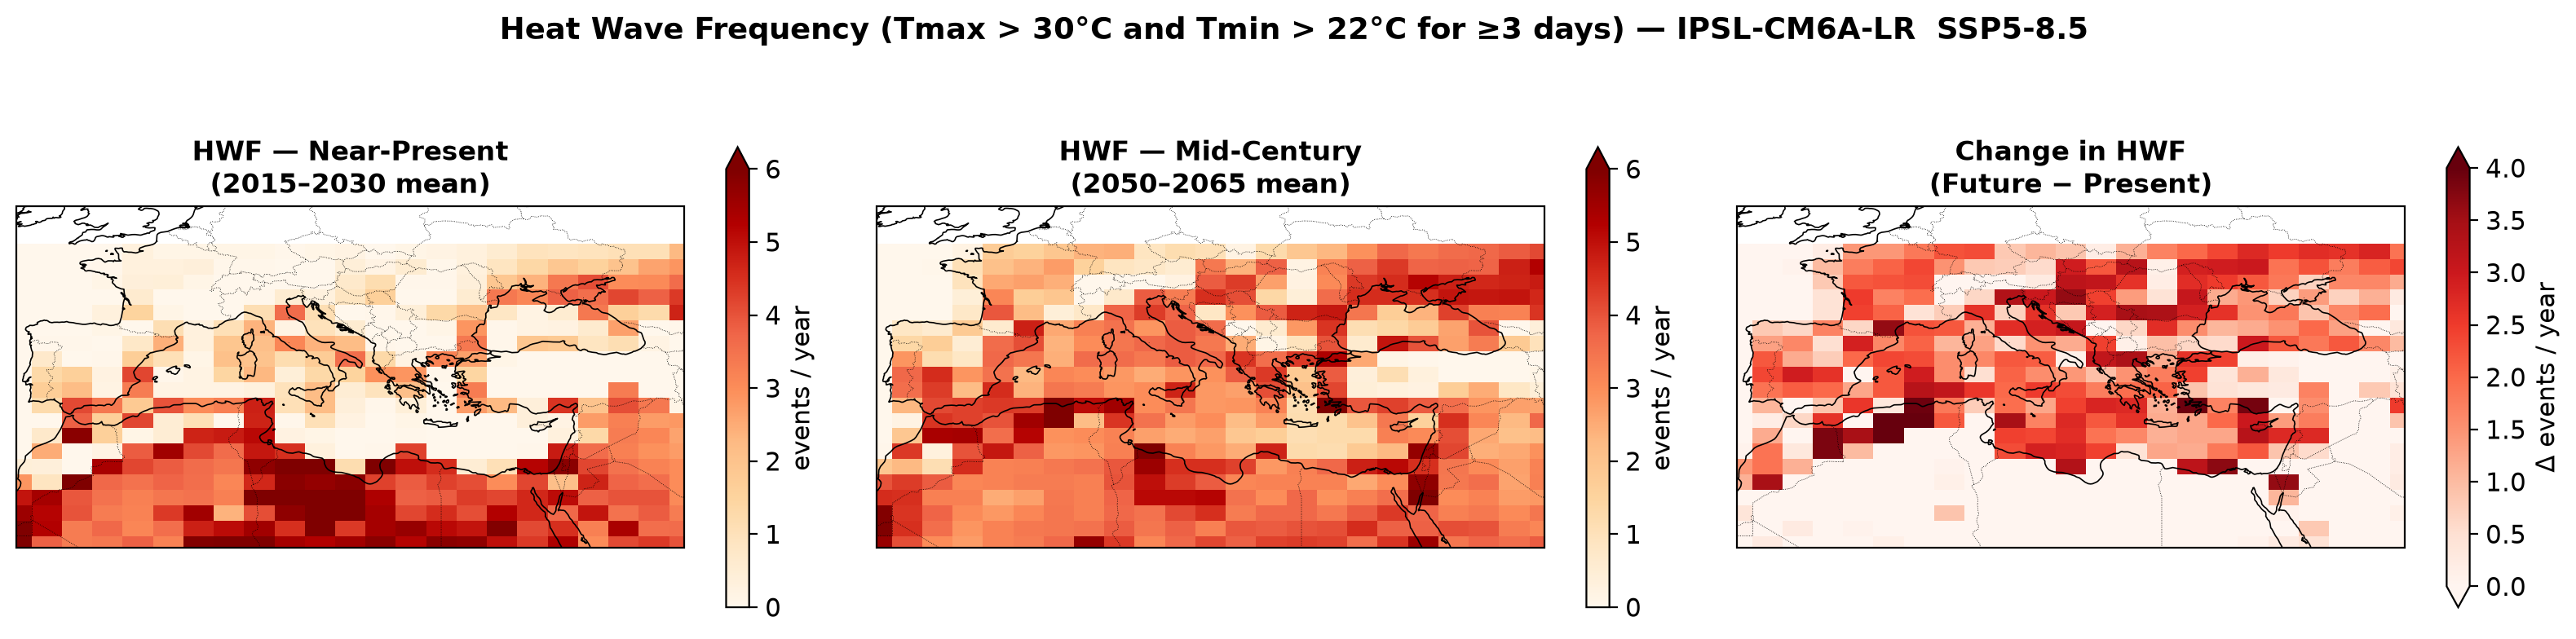

In [ ]:
print("Computing Heat Wave Frequency (HWF) …")

hwf_pres = xclim.atmos.heat_wave_frequency(
    tasmin=tasmin_pres, tasmax=tasmax_pres,
    thresh_tasmin="22 degC", thresh_tasmax="30 degC",
    window=3, freq="YS",
)
hwf_fut = xclim.atmos.heat_wave_frequency(
    tasmin=tasmin_fut, tasmax=tasmax_fut,
    thresh_tasmin="22 degC", thresh_tasmax="30 degC",
    window=3, freq="YS",
)

hwf_pres_mean = hwf_pres.mean("time").compute()
hwf_fut_mean  = hwf_fut.mean("time").compute()

print(f"Mediterranean-average HWF:")
print(f"  Near-present (2015–2030): {float(hwf_pres_mean.mean()):.2f} events/year")
print(f"  Mid-century  (2050–2065): {float(hwf_fut_mean.mean()):.2f} events/year")

# Plot present, future and difference maps
fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()})

for data, ax, title in [
    (hwf_pres_mean, axes[0], "HWF — Near-Present\n(2015–2030 mean)"),
    (hwf_fut_mean,  axes[1], "HWF — Mid-Century\n(2050–2065 mean)"),
]:
    data.plot(ax=ax, cmap="OrRd", vmin=0, vmax=6,
              cbar_kwargs={"shrink": 0.85, "label": "events / year"},
              transform=ccrs.PlateCarree())
    ax.set_title(title)

(hwf_fut_mean - hwf_pres_mean).plot(
    ax=axes[2], cmap="Reds", vmin=0, vmax=4,
    cbar_kwargs={"shrink": 0.85, "label": "Δ events / year"},
    transform=ccrs.PlateCarree())
axes[2].set_title("Change in HWF\n(Future − Present)")

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

fig.suptitle(
    f"Heat Wave Frequency (Tmax > 30°C and Tmin > 22°C for ≥3 days) — {MODEL}  SSP5-8.5",
    fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

> ✏️ **Check your understanding — Temperature Indices**
>
> 1. SU25, TR20, and HWF all increase in the future. Which index shows the **largest relative
>    change** (as a fraction of its present value)?
> 2. Are the spatial patterns of the three indices similar, or does each index highlight a
>    different sub-region of the Mediterranean?
> 3. What would happen to HWF if you increased `window` from 3 to 6 days? Would the count go
>    up or down, and why?
> 4. TR20 is highest along coastlines and in North Africa. Can you explain why?

---

## 🌧️ 5. Precipitation Indices

The Mediterranean precipitation response to climate change is more nuanced than temperature:
total rainfall is projected to **decrease**, but individual extreme events may **intensify**.

This "drying but intensifying" pattern is captured by two complementary indices:

| Index | Code | xclim function | What it measures |
|---|---|---|---|
| 🏜️ Consecutive Dry Days | CDD | `xclim.atmos.maximum_consecutive_dry_days` | Length of the longest annual dry spell (days) |
| ⛈️ Max 5-day precipitation | Rx5day | `xclim.atmos.max_n_day_precipitation_amount` | Peak 5-day rainfall accumulation (mm) |

> 💧 **Unit note:** CMIP6 precipitation is in `kg m⁻² s⁻¹` (equivalent to mm/s).
> xclim automatically converts to mm/day when you write `thresh="1 mm/day"`.
> No manual conversion needed.

### 🏜️ Index 4 — Maximum Consecutive Dry Days (CDD)

**Definition:** The maximum number of **consecutive days with precipitation below 1 mm/day**
in a given year.

```
CDD = max( length of any run where pr < 1 mm/day )  for each year
```

CDD directly quantifies **drought duration** — how long plants, soils, and groundwater go
without meaningful rainfall.

In the Mediterranean, summer is already dry: July–August CDD in southern Spain, Greece,
and North Africa already exceeds 60–90 consecutive days. Under warming, dry seasons start
earlier and end later, extending these already-long dry spells further.

Practical consequences of increasing CDD:
- 🌾 Soil moisture depletion → reduced crop yields and pasture
- 🔥 Vegetation stress → increased wildfire risk
- 💧 Reduced river flow → water supply shortfalls
- 🌊 Hardened, cracked soils → paradoxically, greater flood risk when rainfall finally returns

Computing Maximum Consecutive Dry Days (CDD) …
Mediterranean-average CDD:
  Near-present (2015–2030): 108 days/year
  Mid-century  (2050–2065): 121 days/year


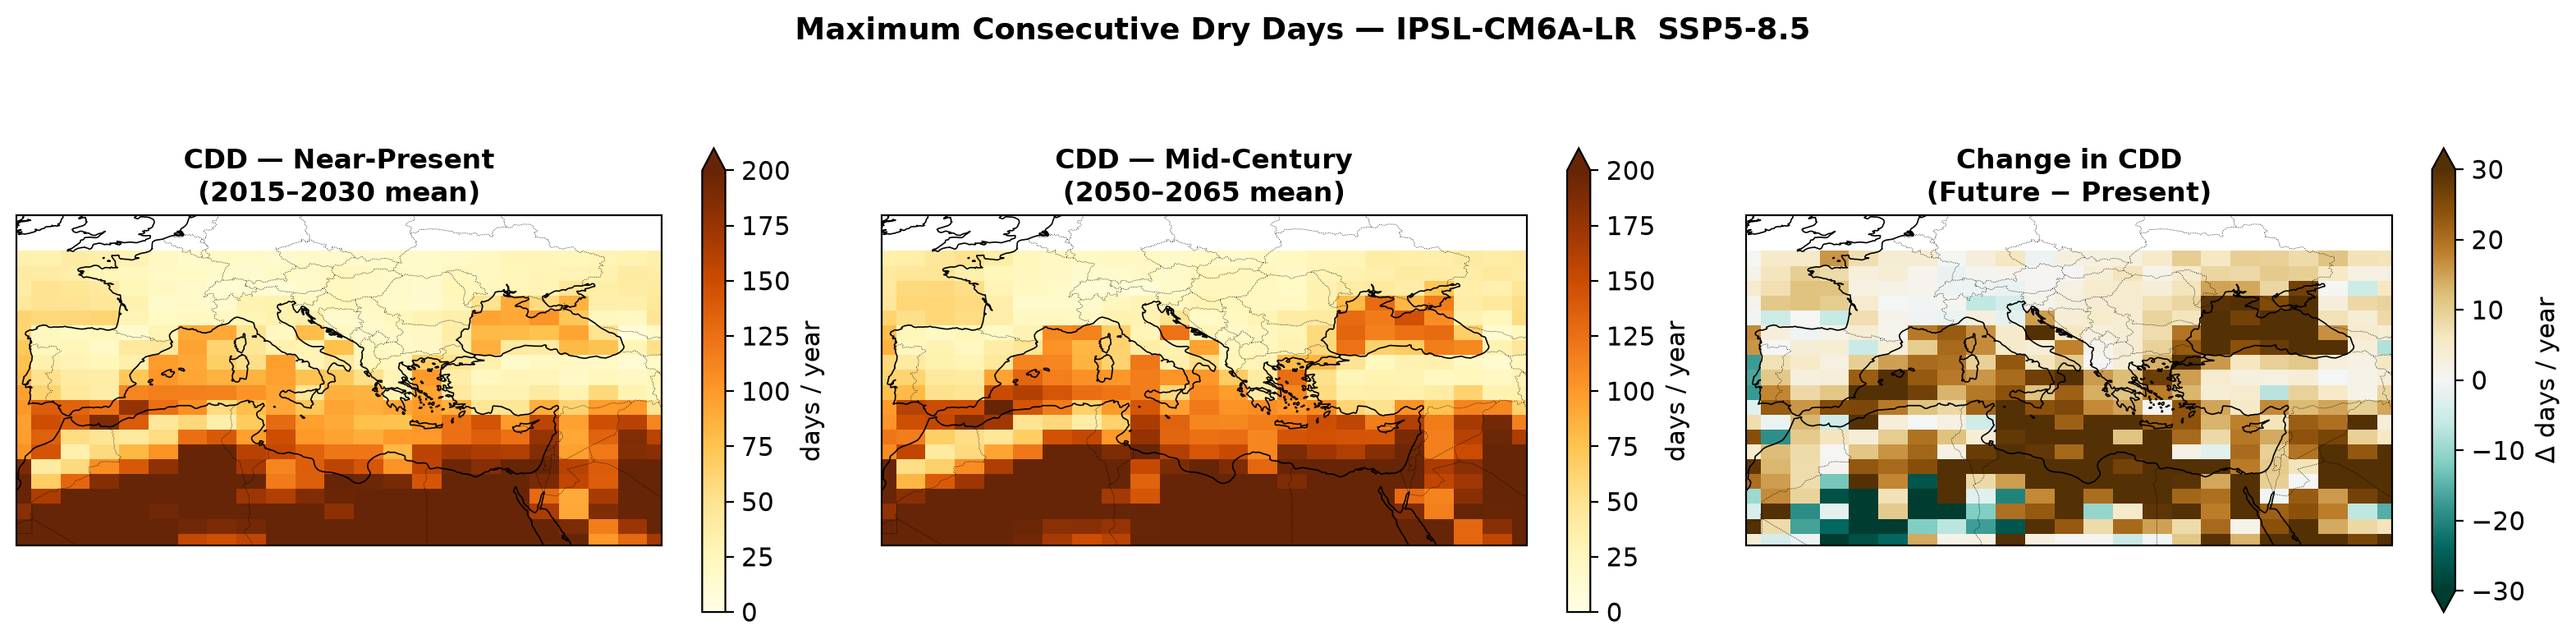

In [12]:
print("Computing Maximum Consecutive Dry Days (CDD) …")

cdd_pres = xclim.atmos.maximum_consecutive_dry_days(
    pr=pr_pres, thresh="1 mm/day", freq="YS"
)
cdd_fut = xclim.atmos.maximum_consecutive_dry_days(
    pr=pr_fut, thresh="1 mm/day", freq="YS"
)

cdd_pres_mean = cdd_pres.mean("time").compute()
cdd_fut_mean  = cdd_fut.mean("time").compute()

print(f"Mediterranean-average CDD:")
print(f"  Near-present (2015–2030): {float(cdd_pres_mean.mean()):.0f} days/year")
print(f"  Mid-century  (2050–2065): {float(cdd_fut_mean.mean()):.0f} days/year")

# Plot present, future and difference maps
fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()})

for data, ax, title in [
    (cdd_pres_mean, axes[0], "CDD — Near-Present\n(2015–2030 mean)"),
    (cdd_fut_mean,  axes[1], "CDD — Mid-Century\n(2050–2065 mean)"),
]:
    data.plot(ax=ax, cmap="YlOrBr", vmin=0, vmax=200,
              cbar_kwargs={"shrink": 0.85, "label": "days / year"},
              transform=ccrs.PlateCarree())
    ax.set_title(title)

(cdd_fut_mean - cdd_pres_mean).plot(
    ax=axes[2], cmap="BrBG_r", vmin=-30, vmax=30,
    cbar_kwargs={"shrink": 0.85, "label": "Δ days / year"},
    transform=ccrs.PlateCarree())
axes[2].set_title("Change in CDD\n(Future − Present)")

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

fig.suptitle(f"Maximum Consecutive Dry Days — {MODEL}  SSP5-8.5",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### ⛈️ Index 5 — Maximum 5-day Precipitation Amount (Rx5day)

**Definition:** The maximum total precipitation accumulated over any **5 consecutive days**
in a given year.

```
Rx5day = max( sum(pr, over sliding window of 5 days) )  for each year
```

Rx5day measures **peak rainfall intensity** — the single most extreme precipitation event
of the year.

Even as total annual precipitation decreases, Rx5day may **increase** in some areas:
when it rains, it rains harder. A warmer atmosphere holds more water vapour (Clausius-Clapeyron
scaling: ~7% more per °C), and when conditions eventually support precipitation, the
release is more intense.

High Rx5day events in the Mediterranean are associated with:
- 🌊 Flash floods, especially in coastal and urban areas
- ⛰️ Landslides on denuded hillsides
- 🏗️ Infrastructure damage from overloaded drainage systems
- ⚠️ Particularly dangerous after long dry spells, when soils cannot absorb rain quickly

Computing Maximum 5-day Precipitation Amount (Rx5day) …
Output units: mm
Mediterranean-average Rx5day:
  Near-present (2015–2030): 53.2 mm / 5 days
  Mid-century  (2050–2065): 51.9 mm / 5 days


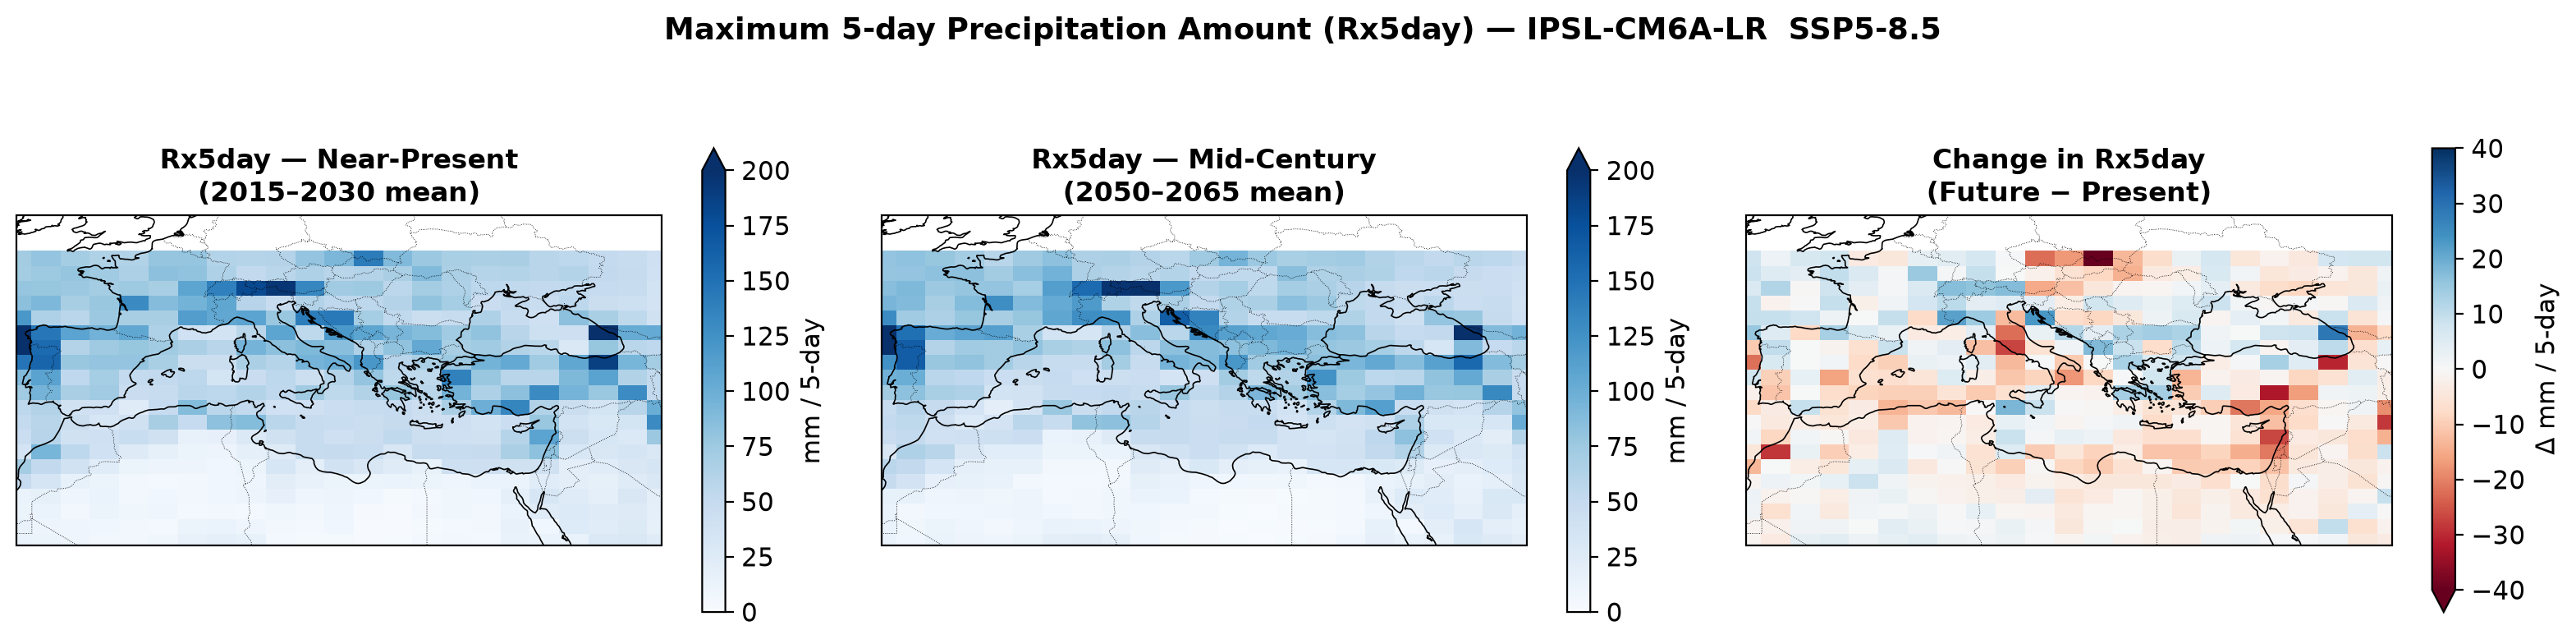

In [13]:
print("Computing Maximum 5-day Precipitation Amount (Rx5day) …")

rx5_pres = xclim.atmos.max_n_day_precipitation_amount(pr=pr_pres, window=5, freq="YS")
rx5_fut  = xclim.atmos.max_n_day_precipitation_amount(pr=pr_fut,  window=5, freq="YS")

rx5_pres_mean = rx5_pres.mean("time").compute()
rx5_fut_mean  = rx5_fut.mean("time").compute()

print(f"Output units: {rx5_pres.attrs.get('units', 'mm')}")
print(f"Mediterranean-average Rx5day:")
print(f"  Near-present (2015–2030): {float(rx5_pres_mean.mean()):.1f} mm / 5 days")
print(f"  Mid-century  (2050–2065): {float(rx5_fut_mean.mean()):.1f} mm / 5 days")

fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                          subplot_kw={"projection": ccrs.PlateCarree()})

for data, ax, title in [
    (rx5_pres_mean, axes[0], "Rx5day — Near-Present\n(2015–2030 mean)"),
    (rx5_fut_mean,  axes[1], "Rx5day — Mid-Century\n(2050–2065 mean)"),
]:
    data.plot(ax=ax, cmap="Blues", vmin=0, vmax=200,
              cbar_kwargs={"shrink": 0.85, "label": "mm / 5-day"},
              transform=ccrs.PlateCarree())
    ax.set_title(title)

(rx5_fut_mean - rx5_pres_mean).plot(
    ax=axes[2], cmap="RdBu", vmin=-40, vmax=40,
    cbar_kwargs={"shrink": 0.85, "label": "Δ mm / 5-day"},
    transform=ccrs.PlateCarree())
axes[2].set_title("Change in Rx5day\n(Future − Present)")

for ax in axes:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=":")
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX])

fig.suptitle(f"Maximum 5-day Precipitation Amount (Rx5day) — {MODEL}  SSP5-8.5",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

> ✏️ **Check your understanding — Precipitation Indices**
>
> 1. CDD increases significantly across the southern Mediterranean, but Rx5day shows a more
>    mixed signal. What does this tell us about the *character* of future Mediterranean precipitation?
> 2. A soil that has experienced 90 dry days is at greater flood risk when a high Rx5day event
>    arrives. Why?
> 3. How would you compute **monthly** CDD instead of annual? What would the `freq` argument be?
> 4. The Rx5day change map shows negative values (wetter) in some parts of the northern
>    Mediterranean. Which areas, and can you suggest a physical reason?

---

## 📈 6. Annual Time Series at a Mediterranean City

Spatial maps show *where* changes occur. A **time series** shows *when* and *how fast* those
changes evolve throughout the 21st century.

We pick a single grid point — 📍 Xanthi, Greece — and compute SU25 and TR20 for the **full
SSP5-8.5 period (2015–2100)**. This reveals the continuous warming signal, year-to-year
variability, and the long-term trend in one view.

Target : Xanthi, Greece (41.133°N, 24.883°E)
Snapped: (40.56°N, 25.00°E)

Computing annual indices for the full 2015–2100 period …
Done.


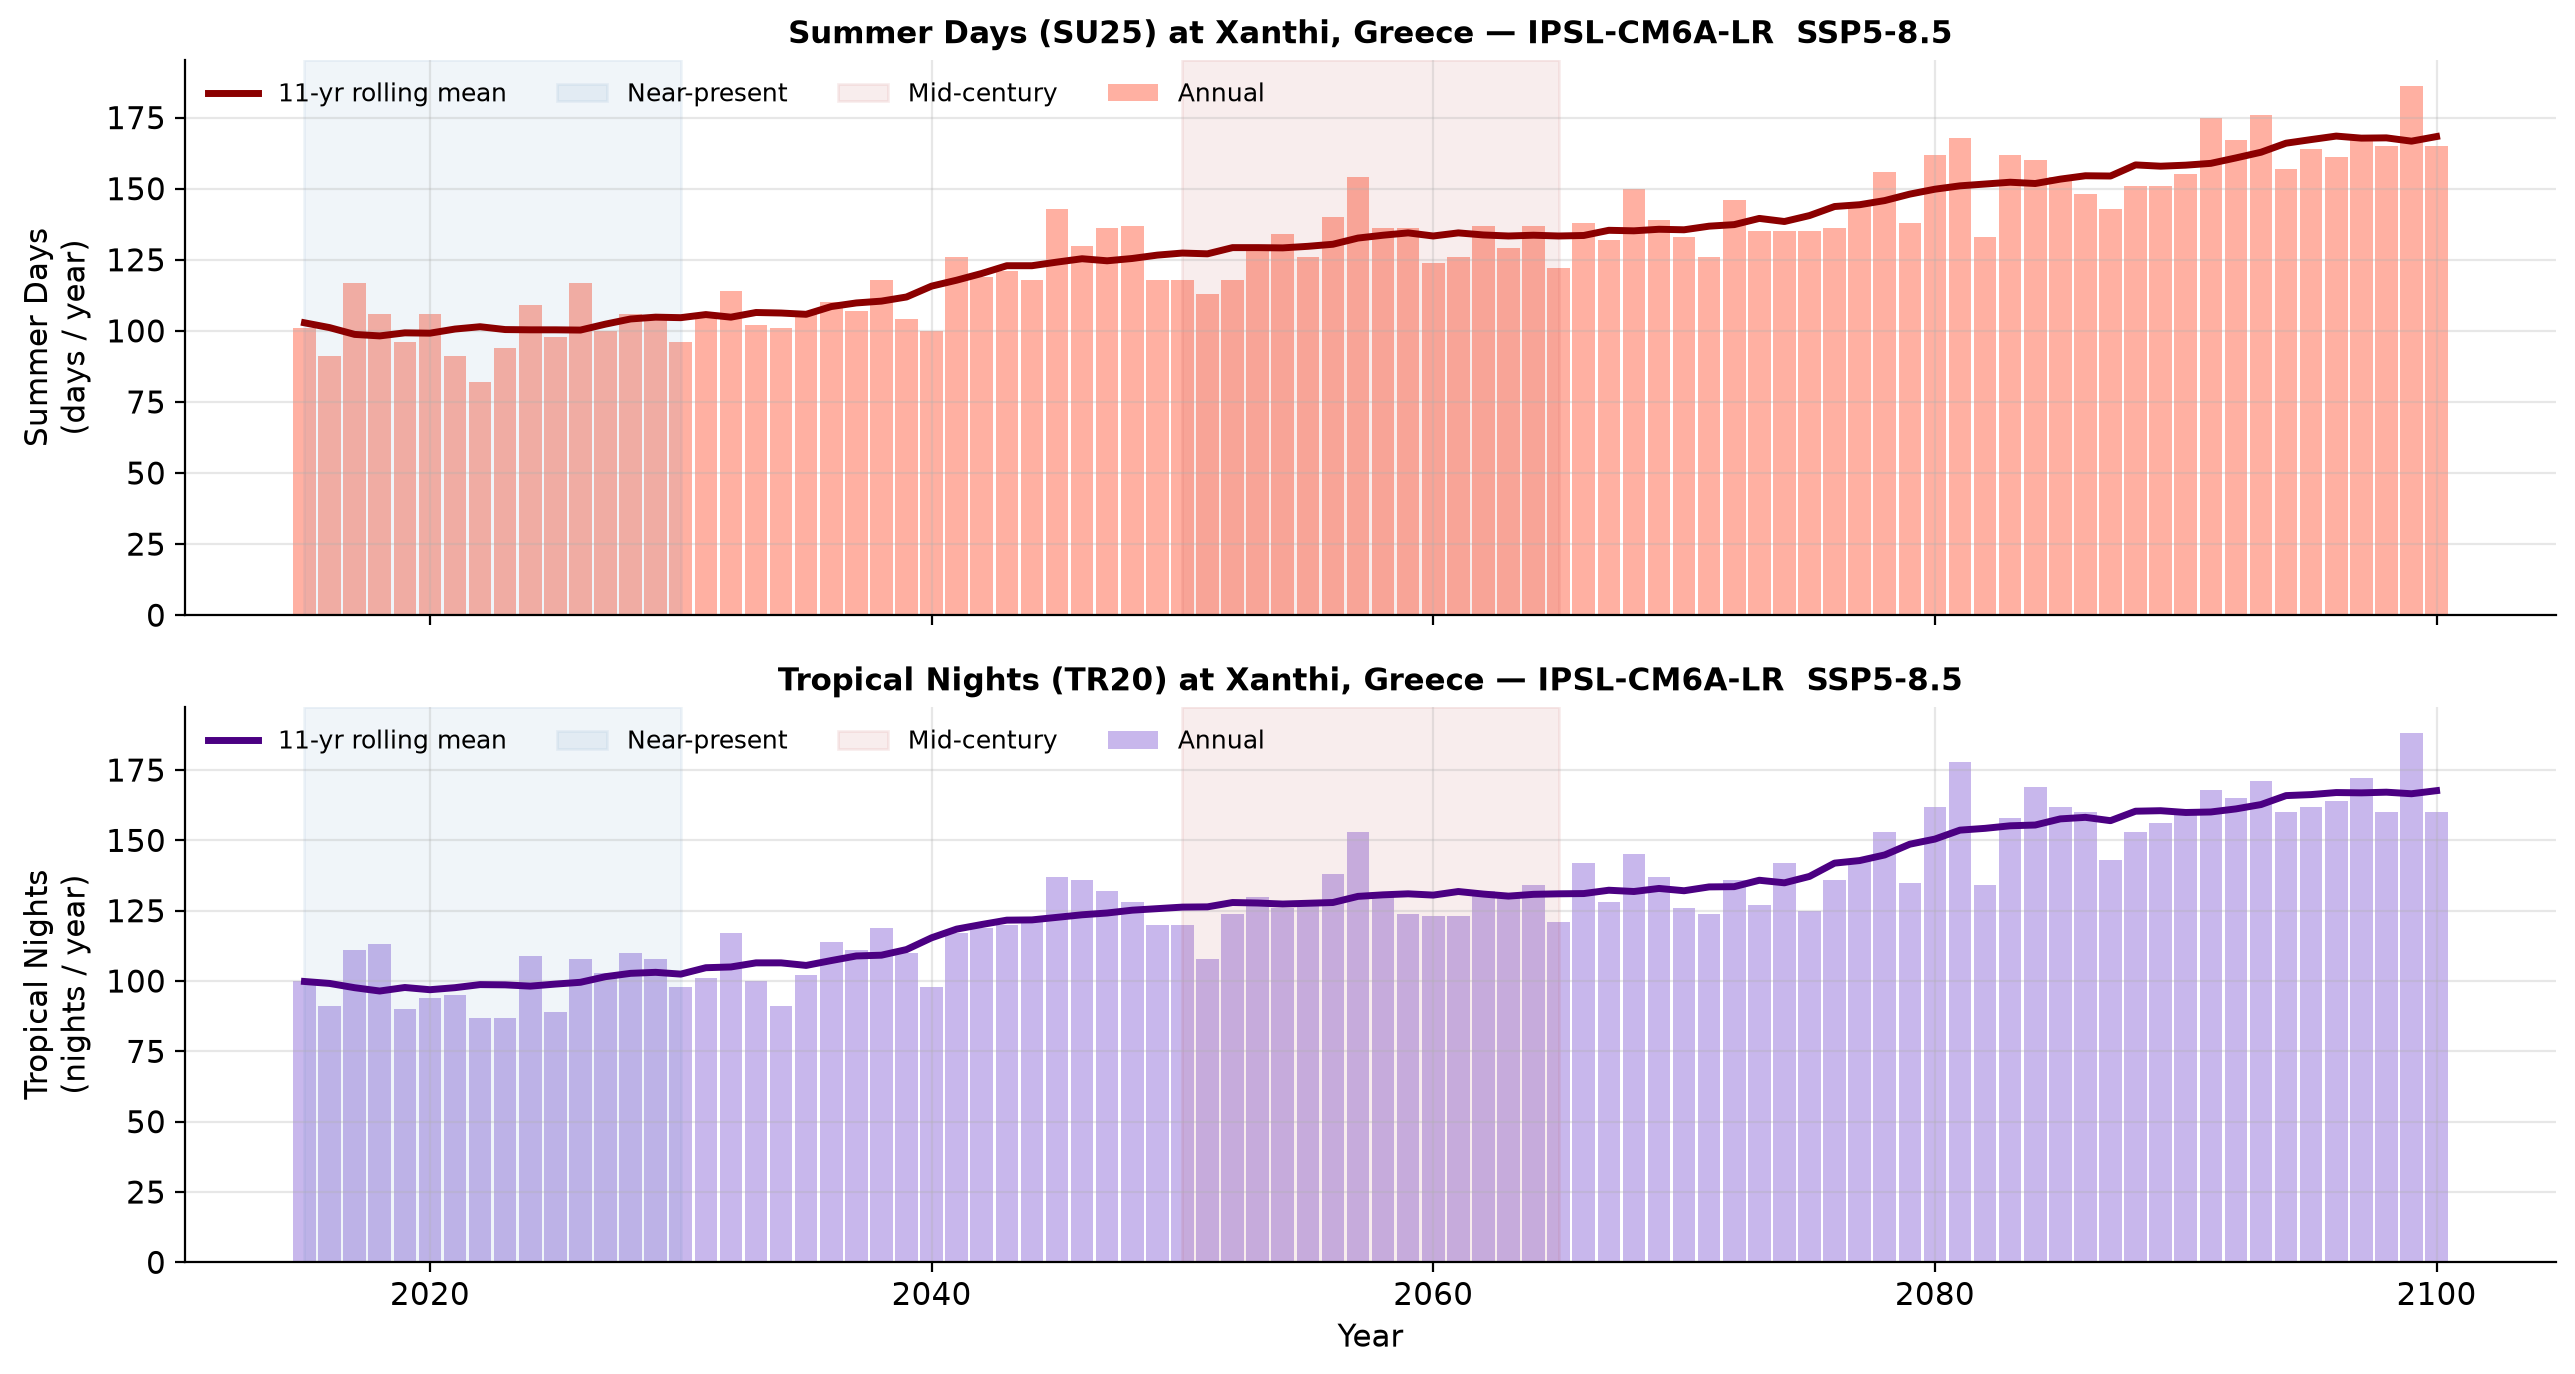


=== Period statistics for Athens ===

Near-present 2015–2030:
  SU25: 100.9 days/year
  TR20: 99.6 nights/year

Mid-century  2050–2065:
  SU25: 129.9 days/year
  TR20: 127.8 nights/year


In [ ]:
# Target location — change to explore other cities
CITY  = "Xanthi, Greece"
C_LAT, C_LON = 41.133, 24.883

# Nearest grid point from the full Mediterranean subset (all years)
tasmax_city = tasmax_med.sel(lat=C_LAT, lon=C_LON, method="nearest")
tasmin_city = tasmin_med.sel(lat=C_LAT, lon=C_LON, method="nearest")

actual_lat = float(tasmax_city.lat)
actual_lon = float(tasmax_city.lon)
print(f"Target : {CITY} ({C_LAT}°N, {C_LON}°E)")
print(f"Snapped: ({actual_lat:.2f}°N, {actual_lon:.2f}°E)")

print("\nComputing annual indices for the full 2015–2100 period …")
su_city = xclim.atmos.tx_days_above(
    tasmax=tasmax_city, thresh="25 degC", freq="YS"
).compute()
tr_city = xclim.atmos.tropical_nights(
    tasmin=tasmin_city, thresh="20 degC", freq="YS"
).compute()
print("Done.")

years = su_city.time.dt.year.values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for ax, data, bar_color, line_color, ylabel, title_text in [
    (ax1, su_city.values,  "tomato",       "darkred",
     "Summer Days\n(days / year)",     f"Summer Days (SU25) at {CITY}"),
    (ax2, tr_city.values,  "mediumpurple", "indigo",
     "Tropical Nights\n(nights / year)", f"Tropical Nights (TR20) at {CITY}"),
]:
    ax.bar(years, data, color=bar_color, alpha=0.5, width=0.9, label="Annual")
    
    # Add 11 years rolling mean
    ax.plot(years,
            pd.Series(data).rolling(11, center=True, min_periods=6).mean(),
            color=line_color, lw=2.5, label="11-yr rolling mean")
    ax.axvspan(2015, 2030, alpha=0.08, color="steelblue", label="Near-present")
    ax.axvspan(2050, 2065, alpha=0.08, color="firebrick",  label="Mid-century")
    
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title_text} — {MODEL}  SSP5-8.5", fontsize=11)
    ax.legend(frameon=False, loc="upper left", ncol=4, fontsize=9)

ax2.set_xlabel("Year")
plt.tight_layout()
plt.show()

# Summary statistics for the two periods
print("\n=== Period statistics for Athens ===")
for label, yr1, yr2 in [("Near-present 2015–2030", 2015, 2030),
                          ("Mid-century  2050–2065", 2050, 2065)]:
    mask = (years >= yr1) & (years <= yr2)
    print(f"\n{label}:")
    print(f"  SU25: {su_city.values[mask].mean():.1f} days/year")
    print(f"  TR20: {tr_city.values[mask].mean():.1f} nights/year")

---

## 🏋️ Exercises

Apply what you have learned. Starter code and hints are provided.

### 📝 Exercise 1 — Hot Days (Tmax > 35 °C)

The standard SU25 index uses a 25 °C threshold, which captures warm days across most of the
Mediterranean. Compute a **"hot days"** index using Tmax > **35 °C** for both climate periods
and map the change.

Questions:
- Where does the 35 °C threshold give substantially different spatial patterns compared with 25 °C?
- Which parts of the Mediterranean already experience many hot days today, and which are just
  entering that regime by mid-century?

In [ ]:
# Exercise 1 — Hot Days (Tmax > 35 °C)
# Hint: the only change from the SU25 cell above is the thresh argument

# hd_pres = xclim.atmos.summer_days(tasmax=tasmax_pres, thresh="35 degC", freq="YS")
# hd_fut  = xclim.atmos.summer_days(tasmax=tasmax_fut,  thresh="35 degC", freq="YS")
# hd_pres_mean = hd_pres.mean("time").compute()
# hd_fut_mean  = hd_fut.mean("time").compute()

# Your plotting code here:


### 📍 Exercise 2 — A Different Mediterranean City

Repeat the point time series analysis (Section 6) for a city of your choice.

| City | Lat | Lon |
|---|---|---|
| 🇮🇹 Rome, Italy | 41.9 | 12.5 |
| 🇪🇬 Cairo, Egypt | 30.1 | 31.2 |
| 🇹🇷 Istanbul, Turkey | 41.0 | 29.0 |
| 🇩🇿 Algiers, Algeria | 36.7 | 3.1 |
| 🇹🇳 Tunis, Tunisia | 36.8 | 10.2 |
| 🇫🇷 Marseille, France | 43.3 | 5.4 |

Compare the trend and magnitude with Athens:
- Which city sees the largest absolute increase in summer days?
- Which city sees the largest absolute increase in tropical nights?
- Can you link the differences to geography (latitude, coastal vs inland, elevation)?

In [ ]:
# Exercise 2 — Change city
CITY2   = "Cairo, Egypt"
C_LAT2  = 30.1
C_LON2  = 31.2

# Your code here:
# 1. Select the nearest grid point from tasmax_med and tasmin_med
# 2. Compute SU25 and TR20 for the full 2015–2100 period
# 3. Plot alongside or compare with Athens results


### 📊 Exercise 3 — Warm Spell Duration Index (WSDI)

The ETCCDI **Warm Spell Duration Index (WSDI)** counts the number of days per year that are
part of a warm spell — a period of at least 6 consecutive days where Tmax exceeds the
**90th percentile** of a reference climatology.

Unlike SU25 (fixed absolute threshold), WSDI uses a **relative threshold** — it detects
anomalously warm days for each location. A day that is "hot" in northern Greece might be
routine in Cairo.

xclim computes WSDI with:

```python
from xclim.core.calendar import percentile_doy

# Step 1: compute the daily 90th percentile from the reference (present) period
tasmax_per90 = percentile_doy(tasmax_pres, per=90).sel(percentiles=90)

# Step 2: compute WSDI for any period using that climatology
wsdi = xclim.atmos.warm_spell_duration_index(
    tasmax=tasmax_da,
    tasmax_per=tasmax_per90,
    freq="YS",
)
```

🔑 **Task:** Compute WSDI for both the present and future period using the present-period
90th percentile as the threshold. How does the spatial pattern of WSDI change compare to SU25?

In [ ]:
# Exercise 3 — Warm Spell Duration Index (WSDI)
# from xclim.core.calendar import percentile_doy

# Step 1: 90th percentile of daily Tmax from the present period
# (percentile_doy computes a day-of-year percentile climatology)
# tasmax_per90 = percentile_doy(tasmax_pres, per=90).sel(percentiles=90)

# Step 2: WSDI for both periods
# wsdi_pres = xclim.atmos.warm_spell_duration_index(
#     tasmax=tasmax_pres, tasmax_per=tasmax_per90, freq="YS"
# )
# wsdi_fut = xclim.atmos.warm_spell_duration_index(
#     tasmax=tasmax_fut, tasmax_per=tasmax_per90, freq="YS"
# )

# Step 3: mean over each period and plot the change
# wsdi_pres_mean = wsdi_pres.mean("time").compute()
# wsdi_fut_mean  = wsdi_fut.mean("time").compute()

# Your plotting code here:


---

## 📋 Summary

### ✅ What we computed

| Index | xclim function | Key parameters | Mediterranean signal (present → mid-century) |
|---|---|---|---|
| ☀️ Summer Days (SU25) | `xclim.atmos.summer_days` | `thresh="25 degC"` | +20–50 additional days/year |
| 🌙 Tropical Nights (TR20) | `xclim.atmos.tropical_nights` | `thresh="20 degC"` | +20–60 additional nights; strongest near the coast |
| 🔥 Heat Wave Frequency (HWF) | `xclim.atmos.heat_wave_frequency` | `window=3`, Tmax>30°C, Tmin>22°C | Approximately doubles |
| 🏜️ Consec. Dry Days (CDD) | `xclim.atmos.maximum_consecutive_dry_days` | `thresh="1 mm/day"` | Increases across southern Mediterranean |
| ⛈️ Rx5day | `xclim.atmos.max_n_day_precipitation_amount` | `window=5` | Mixed: more intense rain despite less total |

### 🌍 The Mediterranean climate change story in five lines

Under SSP5-8.5, the Mediterranean mid-century is projected to experience:
1. ☀️ **≈20–50 more summer days** per year — the thermal summer expands into spring and autumn
2. 🌙 **≈20–60 more tropical nights** per year — overnight heat stress becomes routine in coastal areas
3. 🔥 **Roughly double the heat wave frequency** — from rare to common summer events
4. 🏜️ **Longer consecutive dry spells** — drought risk increases across the southern basin
5. ⛈️ **More intense extreme rainfall** — flash flood risk rises even as total precipitation falls

### 🚀 Going further

- 📊 **Scenario comparison:** repeat with SSP1-2.6 to quantify what climate mitigation achieves
- 🎲 **Ensemble spread:** open multiple models from `df` and plot the inter-model range of each index
- 📅 **Seasonal breakdown:** use `freq="QS-DEC"` for seasonal indices (DJF, MAM, JJA, SON)
- 📚 **WSDI and other ETCCDI:** explore `xclim.atmos.*` — 60+ indicators including growing season length, frost days, and more
- 🔧 **Bias adjustment:** xclim also provides `xclim.sdba` tools for statistical downscaling